### Exploring the Kuramoto Model with time delays for PBM poster project

Sections

* Imports and Implementation
* Approximations - efficiency and drift
* No time delay exploration - 
    * trajectories,
    * synchrony, 
    * coupling strength vs synchrony, 
    * and apparent frequency
* With time delay comparison -
    * approximation effect - approximate vs full delay equation results
    * broken synchrony, 
    * clustered trajectories
    * flat vs travelling wave (space/time), 
    * effect of increasing time delay, (show delay distribution ridge-plot alongside)
    * coupling strength vs apparent frequency trade-off
* Network topologies
    * Plot some network adjacency examples
    * Structural vs Functional connectivities
* Small world network
    * Small world network examples varying rewire probability
    * Plot rewiring probability vs synchrony, delay + non-delay
    * Plot rewiring prob vs coupling strength, delay + non-delay
* Modular network
* HCP data
    * HCP vs modular network comparison

### Imports and implementation

* Global parameters
* Kuramoto
* Kuramoto with delay
* ODE simulation
* Synchrony parameter
* Network stuff? - time delays?

In [12]:
import numpy as np
import networkx as nx
import scipy.stats as stats
from scipy.integrate import odeint
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable


################
# CONFIGURATION
################
C_RED = '#8B0000' # Dark Red
C_BLUE   = '#003366' # Dark Blue
CMAP_BLUE = mcolors.LinearSegmentedColormap.from_list("custom_blue", ['white', C_BLUE])
CMAP_BLUE_INV = mcolors.LinearSegmentedColormap.from_list("custom_blue", [C_BLUE, 'white'])
CMAP_BLUE_RED = mcolors.LinearSegmentedColormap.from_list("custom_blue", [C_BLUE, C_RED])

################
# UTILITY FUNCTIONS
################
# decorator to set random seed then print function and seed
def set_random_seed(func):
    def wrapper(*args, **kwargs):
        seed = np.random.randint(0, 2**31 - 1)
        print(f'Random seed for {func.__name__}: {seed}')
        np.random.seed(seed)
        return func(*args, **kwargs)
    return wrapper
    

################
# KURAMOTO MODEL
################
def kuramoto(theta, t, f, A, e):
    """
    Run iteration of kuramoto model
    
    theta: array of phase values
    t: time
    f: natural frequencies
    A: network adjacency matrix
    e: coupling strength
    
    Returns: array of phase values
    """
    phase_diff = theta[None, :] - theta[:, None]  # θ_j - θ_i
    coupling = np.sum(A * np.sin(phase_diff), axis=1)
    return f + e * coupling

def dkuramoto(theta, t, f, A, e, alpha):
    """
    Run iteration of kuramoto model
    
    theta: array of phase values
    t: time
    f: natural frequencies
    A: network adjacency matrix
    e: coupling strength
    alpha: phase lag matrix - time delay matrix * natural frequency
    
    Returns: array of phase values
    """
    phase_diff = theta[None, :] - theta[:, None]  # θ_j - θ_i
    coupling = np.sum(A * np.sin(phase_diff - alpha), axis=1)
    return f + e * coupling

def run_kuramoto(A, f, theta_0, e, t, D=None):
    """
    Run kuramoto model over time grid. If delay matrix is passed, uses the delay model (with approximation phase lags preclculated)
    
    A: network adjacency matrix
    f: natural frequencies
    theta_0: initial phase values
    e: coupling strength
    t: time grid
    D: delay matrix
    
    Returns: array per time step of phase values, 
    """
    if D is None:
        theta = odeint(kuramoto, theta_0, t, args=(f, A, e))
    else:
        alpha = np.mean(f) * D  # Calculate phase lags once outside of kuramoto function for efficiency
        theta = odeint(dkuramoto, theta_0, t, args=(f, A, e, alpha))
    return theta

#################
# METRICS
#################


def truncate_time(theta, fraction=0.2):
    cutoff = int(theta.shape[0] * (1 - fraction))
    return theta[cutoff:]

def get_order_parameter(theta):
    """
    Calculates the Order Parameter R(t)
    R = |(1/N) * sum(exp(i * theta))|
    Returns: Array of R values over time (0 to 1)
    """
    z = np.mean(np.exp(1j * theta), axis=1)
    return np.abs(z)

def get_winding_number(theta):
    """Calculates Topological Winding Number (m)."""
    theta_steady = truncate_time(theta)
    N = theta.shape[1]
    diffs = np.angle(np.exp(1j * np.diff(theta_steady, axis=1)))
    mean_diff = np.mean(diffs)
    m = (mean_diff * N) / (2 * np.pi)
    return m

def get_phase_velocity(theta, dt):
    """Calculates Wave Speed (Nodes/s)."""
    theta_steady = truncate_time(theta)
    d_theta_dt = np.mean(np.diff(theta_steady, axis=0)) / dt
    d_theta_dx = np.mean(np.angle(np.exp(1j * np.diff(theta_steady, axis=1))))
    if np.abs(d_theta_dx) < 1e-3: return 0.0
    return np.abs(d_theta_dt / d_theta_dx)

def get_spatial_coherence(theta):
    """Calculates Spatial Coherence (Neighbor Stability 0-1)."""
    theta_steady = truncate_time(theta)
    diffs = np.angle(np.exp(1j * np.diff(theta_steady, axis=1)))
    R_diff = np.abs(np.mean(np.exp(1j * diffs)))
    return R_diff


def calculate_metrics_over_time(theta, dt, coherence_threshold=0.4):
    """
    Calculates evolution of metrics, but masks Winding/Speed if Coherence is low.
    """
    # 1. Global Synchrony (R)
    synchrony = np.abs(np.mean(np.exp(1j * theta), axis=1))

    # 2. Neighbor Differences
    diffs_all = np.hstack([np.diff(theta, axis=1), theta[:, 0:1] - theta[:, -1:]])
    diffs_wrapped = np.angle(np.exp(1j * diffs_all))
    
    # 3. Spatial Coherence (The Gatekeeper)
    coherence = np.abs(np.mean(np.exp(1j * diffs_wrapped), axis=1))
    
    # --- GATING LOGIC ---
    # Create a mask where the system is too disordered to have a "speed" or "mode"
    is_disordered = coherence < coherence_threshold
    
    # 4. Winding Number
    # Calculate everywhere, then apply mask
    winding = np.sum(diffs_wrapped, axis=1) / (2 * np.pi)
    winding[is_disordered] = np.nan  # Hide metric if no structure exists
    
    # 5. Wave Speed
    d_theta_dt = np.diff(theta, axis=0) / dt
    mean_omega = np.mean(d_theta_dt, axis=1)
    mean_k = np.mean(diffs_wrapped, axis=1)
    
    speed = np.zeros_like(synchrony)
    # Only calculate speed where:
    # A) Coherence is high enough
    # B) Wavenumber k is not zero (avoid divide-by-zero)
    # C) We are not at the very last time step (due to np.diff alignment)
    
    valid_mask = (~is_disordered[:-1]) & (np.abs(mean_k[:-1]) > 1e-3)
    
    # Initialize with NaNs so gaps appear in the plot
    speed[:] = np.nan
    speed[:-1][valid_mask] = np.abs(mean_omega[valid_mask] / mean_k[:-1][valid_mask])
    
    return {
        'synchrony': synchrony,
        'coherence': coherence,
        'winding': winding,
        'speed': speed
    }

#################
# INITIAL PHASES
#################

@set_random_seed
def get_initial_phases(N, mode='random', wrap=True, **kwargs):
    """
    Generate initial phases
    
    Args:
        N (int): Number of nodes
        mode (str): 'random', 'ordered', 'normal', 'multimodal'
        wrap (bool): Wrap phases to [-pi, pi]
        **kwargs: Parameters specific to the chosen mode:
            'uniform': None
            'ordered': None
            'normal': None
            'clustered': None
            
    Returns:
        np.ndarray: Weighted delay matrix masked by A
    """
    # Generate initial phases based on mode
    if mode == 'uniform':
        theta0 = np.random.uniform(-np.pi, np.pi, N)
        
    elif mode == 'ordered':
        theta0 = sorted(np.random.uniform(-np.pi, np.pi, N))
        
    elif mode == 'normal':
        theta0 = np.random.normal(0, np.pi/24, N)
        
    elif mode == 'clustered':
        n_cluster = N // 3
        n_remainder = N - (n_cluster * 2) 
        c1 = np.random.normal(-2*np.pi/3, np.pi/24, n_cluster)
        c2 = np.random.normal(0, np.pi/24, n_cluster)
        c3 = np.random.normal(2*np.pi/3, np.pi/24, n_remainder)
        theta0 = np.concatenate((c1, c2, c3))
    
    # Wrap phases
    if wrap:
        theta0 = theta0 % (2 * np.pi)
    
    return theta0

################
# DELAYS
################

def force_symmetry(A):
    return np.triu(A) + np.triu(A, 1).T

@set_random_seed
def get_time_delays(A, mode='constant', symmetric=False, **kwargs):
    """
    Master function to generate time delay matrices.
    
    Args:
        A (np.ndarray): Adjacency matrix (NxN)
        mode (str): 'constant', 'normal', 'uniform', or 'geometric'
        symmetric (bool): If True, ensures D_ij == D_ji (undirected delays)
        **kwargs: Parameters specific to the chosen mode:
            - constant: 'delay' (float)
            - normal:   'mean', 'std'
            - uniform:  'min', 'max'
            - geometric: 'velocity'
            
    Returns:
        np.ndarray: Weighted delay matrix masked by A
    """
    N = A.shape[0]
    
    # Generate delays
    if mode == 'constant':
        val = kwargs.get('delay', 0.0)
        D = np.ones((N, N)) * val
        
    elif mode == 'normal':
        mean = kwargs.get('mean', 0.0)
        std = kwargs.get('std', 0.0)
        D = np.abs(np.random.normal(mean, std, (N, N)))
        
    elif mode == 'uniform':
        min_d = kwargs.get('min', 0.0)
        max_d = kwargs.get('max', 0.0)
        D = np.abs(np.random.uniform(min_d, max_d, (N, N)))
    elif mode == 'geometric':
        velocity = kwargs.get('velocity', 15.0)
        theta = np.linspace(0, 2*np.pi, N, endpoint=False)
        coords = np.column_stack([np.cos(theta), np.sin(theta)])
        dist_matrix = squareform(pdist(coords))
        D = dist_matrix / velocity
        
        # Add noise
        noise_std = kwargs.get('noise_std', 0.0)
        if noise_std > 0:
            jitter = np.random.normal(0, noise_std, (N, N))
            D = D * np.abs(1 + jitter)
            if symmetric:
                D = (D + D.T) / 2
    
    # Force symmetry - not natural, but simpler simulation
    if symmetric:
        D = force_symmetry(D)
        
    # Mask delays with connectivity
    D = D * (A > 0).astype(float)
    
    return D


#################
# NETWORKS
#################

def get_circulant_network(N, p):
    """Generate circulant network with p% neighbouring connections, symmetrically distributed"""
    k = int(p * N)
    offsets = [i+1 for i in range(k)]
    A = nx.circulant_graph(N, offsets) 
    return nx.to_numpy_array(A)


def get_smallworld_network(N, p, rewire_prob):
    k = int(p * N)
    A = nx.watts_strogatz_graph(N, k, rewire_prob)
    return nx.to_numpy_array(A)


###################
# PHASE MANIPULATIONS
###################
def relative_phase(theta):
    mean_phases = np.angle(np.mean(np.exp(1j * theta), axis=1))
    unwrapped_sol = np.unwrap(theta, axis=0)
    unwrapped_mean = np.unwrap(mean_phases)
    relative = unwrapped_sol - unwrapped_mean[:, None]
    return relative

def relative_phase(theta):
        psi = np.angle(np.mean(np.exp(1j * theta), axis=1))
        relative_phases = np.angle(np.exp(1j * (theta - psi[:, None])))
        return relative_phases
    
def relative_phase_node0(theta):
    ref_node = theta[:, 0] 
    relative = np.angle(np.exp(1j * (theta - ref_node[:, None])))
    return relative

######################
# PLOTTING
######################

def plot_adjacency_matrix(A, ax=None, vmin=0, vmax=1, cmap=CMAP_BLUE, colorbar=False, cbar_label=None):
    if ax is None:
        fig, ax = plt.subplots()
        
    im = ax.imshow(A, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    
    if colorbar:
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        cbar = plt.colorbar(im, cax=cax)
        if cbar_label:
            cbar.set_label(cbar_label)

    if ax is None:
        ax.set_xlabel("Node Index")
        ax.set_ylabel("Node Index")
        plt.show()

def plot_adjacency_matrix_with_delay(A, D):
    fig, ax = plt.subplots(1, 2, figsize=(8, 5))
    ax[0].imshow(A, cmap=CMAP_BLUE)
    ax[0].set_title("Adjacency Matrix")
    ax[0].set_xlabel("Node Index")
    # ax[0].tick_params(axis='x', labeltop=True, labelbottom=False)
    ax[0].set_ylabel("Node Index")
    ax[1].imshow(D, cmap=CMAP_BLUE)
    ax[1].set_title("Delay Matrix")
    ax[1].set_xlabel("Node Index")
    # ax[1].tick_params(axis='x', labeltop=True, labelbottom=False)
    ax[1].set_ylabel("Node Index")
    plt.tight_layout()
    plt.show()

def plot_trajectory_vs_synchrony(t_eval, thetas, R_km, phase=True, unwrap=True, add_text=None):
    fig, ax1 = plt.subplots(figsize=(8, 5))
    
    # Plot trajectories
    if phase:
        ax1.plot(t_eval, relative_phase(thetas), '.', markersize=.05, color=C_BLUE, lw=0.5, alpha=0.25, label='Relative Phase Trajectories')
        ax1.set_ylim(-np.pi-0.1, np.pi+0.1)
        ax1.set_ylabel(r'$\theta$', color=C_BLUE)
    else:
        ax1.plot(t_eval, np.sin(thetas), color=C_BLUE, lw=0.5, alpha=0.25, label='Trajectories')
        ax1.set_ylim(-1.1, 1.1)
        ax1.set_ylabel(r'$\sin(\theta)$', color=C_BLUE)
    ax1.set_xlabel(r'Time (s)')
    ax1.tick_params(axis='y', labelcolor=C_BLUE) 

    # Plot order parameter (sin of phase)
    ax2 = ax1.twinx()
    ax2.plot(t_eval, R_km, color=C_RED, lw=2, alpha=1, label='Synchrony')
    ax2.set_ylabel(r'$R(t)$', color=C_RED)
    ax2.set_xlabel(r'Time (s)')
    ax2.tick_params(axis='y', labelcolor=C_RED) 
    ax2.set_ylim(-0.05, 1.05)
    
    if add_text:
        add_text_box(ax1, add_text, location="top-left")

    # if phase:
    #     plt.title("Relative Phase Trajectories vs. Synchrony")
    # else:
    #     plt.title("Trajectories vs. Synchrony")
    plt.tight_layout()
    plt.show()  
    
def add_text_box(ax, text_str, location="bottom-left"):
    """Prints arbitrary text."""

    if location == "top-left":
        x, y = 0.03, 0.95
        va, ha = "top", "left"
    else:  # default bottom-left
        x, y = 0.03, 0.05
        va, ha = "bottom", "left"

    ax.text(
        x, y, text_str,
        transform=ax.transAxes,
        fontsize=10,
        fontweight='bold',
        color='#8B0000',
        verticalalignment=va,
        horizontalalignment=ha,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor='white',
            edgecolor='#8B0000',
            alpha=0.8
        )
    )
    
def add_metrics_box(ax, theta, dt, metrics=['winding', 'coherence']):
    """Prints steady-state metrics in a dark red box on the plot."""
    results = []
    if 'winding' in metrics:
        val = get_winding_number(theta)
        results.append(f"Winding #: {val:.2f}")
    if 'velocity' in metrics:
        val = get_phase_velocity(theta, dt)
        results.append(f"Speed: {val:.1f} nodes/s")
    if 'coherence' in metrics:
        val = get_spatial_coherence(theta)
        results.append(f"Coherence: {val:.2f}")
    if 'synchrony' in metrics:
        order = get_order_parameter(theta)
        val = order[-1]
        results.append(f"Synchrony: {val:.2f}")
        
    text_str = "\n".join(results)
    add_text_box(ax, text_str)     
    
def plot_spacetime_heatmap(phases, duration, A, ax=None, metrics=None, cutoff=None, colorbar=False, cbar_label=None):
    """
    Plots the space-time evolution of phases.
    """
    # Plotting Parameters
    x0, xn = 0, A.shape[0]
    y0, yn = duration, 0 # Standard: Time 0 at top
    
    # Truncate trajectories
    if cutoff:
        phases = truncate_time(phases, cutoff)
        yn = (1 - cutoff) * duration # Update start time if truncated
    
    if ax is None:
        fig, ax = plt.subplots()
    
    # Plot Heatmap
    im = ax.imshow(np.sin(phases), aspect='auto', cmap=CMAP_BLUE, 
                   extent=[x0, xn, y0, yn], 
                   origin='upper',
                   vmin=-1, vmax=1)
    
    # Add Colorbar if requested
    if colorbar:
        # Create a divider to append the colorbar to the existing axis
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        cbar = plt.colorbar(im, cax=cax)
        if cbar_label:
            cbar.set_label(cbar_label)
            
    # Add Metrics Box
    if metrics is not None:
        add_metrics_box(ax, phases, duration, metrics)

    # Labels (only if standalone)
    if ax is None:
        ax.set_xlabel("Node Index")
        ax.set_ylabel("Time (s)")
        ax.set_title("Space-Time Heatmap")
        plt.show()

#### No Delay trajectories convergence
* run kuramoto
* show convergence of trajectories (sin(phase))

Random seed for get_initial_phases: 1515631902
Random seed for get_time_delays: 659940448
Running No Delay Model...


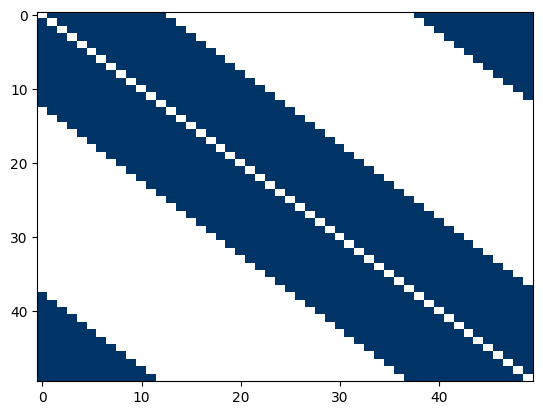

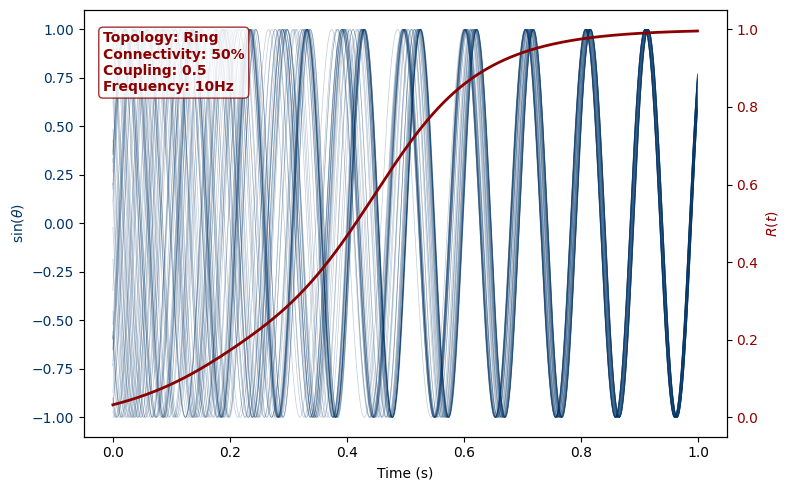

In [2]:
# Parameters
N = 50  # Number of nodes (Small enough to see lines clearly)
DURATION = 1.          # Seconds
DT = 0.001             # Time step
t_eval = np.arange(0, DURATION, DT)
FREQ = 10 * 2 * np.pi  # 10Hz natural frequency
f = [FREQ]*N
theta_0 = get_initial_phases(N, mode='uniform')
e = 0.5  # Coupling strength

# Ring with 50% connectivity
A = get_circulant_network(N, 0.25)
D = get_time_delays(A, 'uniform', min=0.002, max=0.062)  # Uniform - values from paper

# Run models
print("Running No Delay Model...")
KM = run_kuramoto(A, f, theta_0, e, t_eval, D=None)
R_km = get_order_parameter(KM)

# Plots
plot_adjacency_matrix(A)
text = 'Topology: Ring\nConnectivity: 50%\nCoupling: 0.5\nFrequency: 10Hz'
plot_trajectory_vs_synchrony(t_eval, KM, R_km, phase=False, add_text=text)


#### Example with delay
* run both
* show phase trajectories - including organic pattern
* show order parameter plot

Random seed for get_initial_phases: 797891225
Random seed for get_time_delays: 724716430
Running Delay Model...


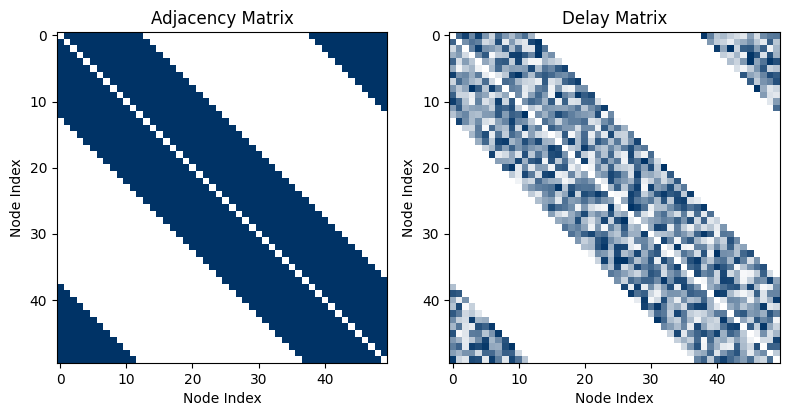

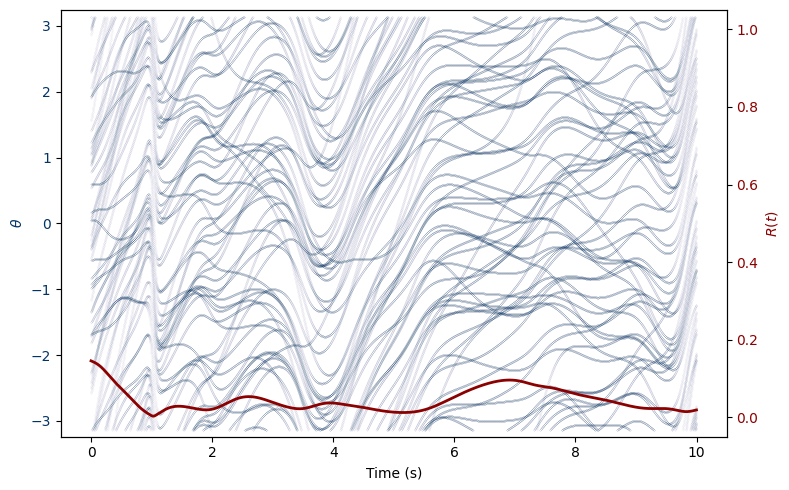

In [3]:
# Parameters
N = 50  # Number of nodes (Small enough to see lines clearly)
DURATION = 10.0          # Seconds
DT = 0.001             # Time step
t_eval = np.arange(0, DURATION, DT)
FREQ = 10 * 2 * np.pi  # 10Hz natural frequency
f = [FREQ]*N
theta_0 = get_initial_phases(N, mode='uniform')
e = 0.5  # Coupling strength

# Ring with 50% connectivity
A = get_circulant_network(N, 0.25)
D = get_time_delays(A, 'uniform', min=0.002, max=0.062)  # Uniform - values from paper

# Run model
print("Running Delay Model...")
dKM = run_kuramoto(A, f, theta_0, e, t_eval, D=D)
R_dkm = get_order_parameter(dKM)

# Plots
plot_adjacency_matrix_with_delay(A, D)
plot_trajectory_vs_synchrony(t_eval, dKM, R_dkm, phase=True)

#### Synchrony degradation with increasing delay
* generate delay distributions
* run delay kuramoto for each
* plot order parameter line for each
* plot distributions as ridge plot

Random seed for get_initial_phases: 1279962063
Random seed for get_initial_phases: 636945121
Random seed for get_initial_phases: 1395783264
Random seed for get_initial_phases: 722683892
Random seed for get_initial_phases: 176043454
Random seed for get_initial_phases: 243688269
Random seed for get_initial_phases: 1795220746
Random seed for get_initial_phases: 1136463664
Random seed for get_initial_phases: 101295024
Random seed for get_initial_phases: 2035022477
Random seed for get_time_delays: 547658299
Random seed for get_time_delays: 1489171841
Random seed for get_time_delays: 1575810397
Random seed for get_time_delays: 1378275796
Random seed for get_time_delays: 737142518
Random seed for get_time_delays: 245144484
Random seed for get_time_delays: 1418936605
Random seed for get_time_delays: 79077634
Random seed for get_time_delays: 42394160
Random seed for get_time_delays: 1027653212
Random seed for get_time_delays: 518493919
Random seed for get_time_delays: 1995318529
Random seed for

C:\Users\dgsan\AppData\Local\Temp\ipykernel_30156\187448408.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('GnBu_r')
C:\Users\dgsan\AppData\Local\Temp\ipykernel_30156\187448408.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


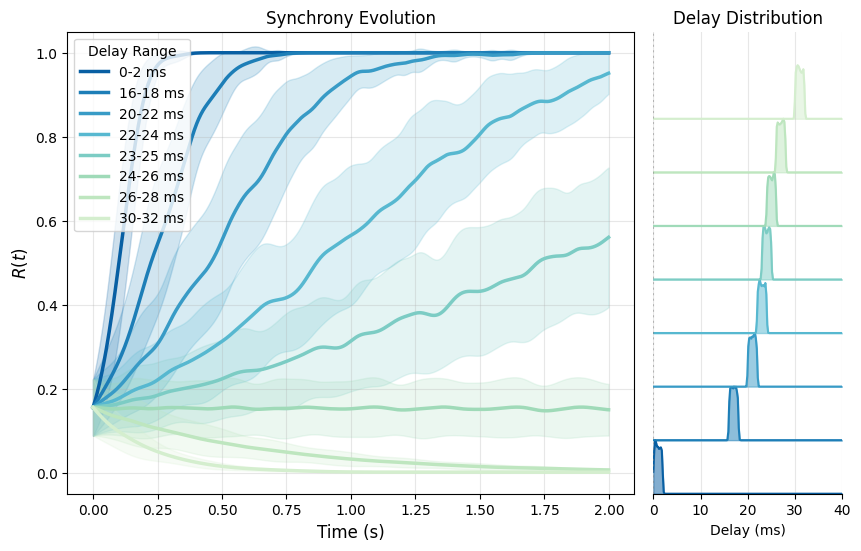

In [7]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy.stats as stats
import numpy as np

PLOT_STD = True       # Toggle fill_between for Standard Deviation
PLOT_POINTS = False   # Toggle scatter points (True) vs Line plots (False)

N = 50          # Number of nodes
DURATION = 2.0  # Seconds
DT = 0.001      # Time step
t_eval = np.arange(0, DURATION, DT)
FREQ = 10 * 2 * np.pi  # 10Hz natural frequency
f = [FREQ]*N
e = 0.5         # Coupling strength
N_RUNS = 10      # Number of simulations to average per delay set

# Ring with 50% connectivity
A = get_circulant_network(N, 0.5)

# Delay Ranges to Test (min_ms, max_ms)
delays = [
    (0, 2),
    (10, 12),
    (16, 18),
    (20, 22),
    (22, 24),
    (24, 26),
    (30, 32),
]
delays = [
    (0, 2),
    (16, 18),
    (20, 22),
    (22, 24),
    (23, 25),
    (24, 26),
    (26, 28),
    (30, 32),
]

# Generate initial phases upfront so each run uses the same set for each delay set
theta0s = []
for i in range(N_RUNS):
    theta_run = get_initial_phases(N, mode='uniform')
    theta0s.append(theta_run)

results_mean = []   # stores Mean R(t) for each delay set
results_std = []    # stores Std Dev of R(t) for each delay set
example_Ds = []     # stores one example Delay Matrix per set (for Ridge Plot)

for min_ms, max_ms in delays:
    # print(f'Running {N_RUNS} trials for delays in ({min_ms}, {max_ms}) ms...')
    
    batch_Rs = [] # Temporary list for this delay set
    
    for run in range(N_RUNS):
        theta_run = theta0s[run]
        D = get_time_delays(A, 'uniform', min=min_ms/1000, max=max_ms/1000)
        dKM = run_kuramoto(A, f, theta_run, e, t_eval, D=D)
        R_t = get_order_parameter(dKM)
        batch_Rs.append(R_t)
        if run == 0:
            example_Ds.append(D)
    
    # Calculate Statistics across the batch (axis=0 is the run index)
    batch_array = np.array(batch_Rs)
    results_mean.append(np.mean(batch_array, axis=0))
    results_std.append(np.std(batch_array, axis=0))

# Set up plots
cmap = cm.get_cmap('GnBu_r') 
colors = [cmap(i) for i in np.linspace(0.1, 0.8, len(delays))]

fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[3, 1], wspace=0.05)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])

# Plot order param with std
for i, (min_d, max_d) in enumerate(delays):
    label = f"{min_d}-{max_d} ms"
    mean_R = results_mean[i]
    std_R = results_std[i]
    
    if PLOT_POINTS:
        # Plot just points (downsampled for readability if needed)
        step = 10 # Plot every 10th point to avoid clutter
        ax0.scatter(t_eval[::step], mean_R[::step], color=colors[i], s=10, label=label if i==0 else "")
    else:
        # Plot Mean Line
        ax0.plot(t_eval, mean_R, color=colors[i], lw=2.5, label=label)
        
        # Plot Standard Deviation Area
        if PLOT_STD:
            ax0.fill_between(t_eval, mean_R - std_R, mean_R + std_R, color=colors[i], alpha=0.2)

ax0.set_ylabel(r'$R(t)$', fontsize=12)
ax0.set_xlabel('Time (s)', fontsize=12)
ax0.set_title(f'Synchrony Evolution', fontsize=12)
ax0.set_ylim(-0.05, 1.05)
ax0.grid(True, alpha=0.3)
ax0.legend(loc='upper left', title="Delay Range")

# Ridge plot
spacing = 0.8 

for i, d_matrix in enumerate(example_Ds):
    # Flatten and Filter (Convert to ms)
    flat_delays = d_matrix[d_matrix > 0] * 1000
    base_y = i * spacing 
    
    # Handle Zero Delay Case
    if len(flat_delays) == 0:
        ax1.plot([0, 0], [base_y, base_y + 0.8], color=colors[i], lw=2)
        continue

    # Calculate Density
    density = stats.gaussian_kde(flat_delays)
    x_vals = np.linspace(0, 40, 200) # Fixed range matching xlim
    y_vals = density(x_vals)
    if np.max(y_vals) > 0:
        y_vals = y_vals / np.max(y_vals) * 0.8 
    shifted_y = y_vals + base_y
    ax1.plot(x_vals, shifted_y, color=colors[i], lw=1.5)
    ax1.fill_between(x_vals, base_y, shifted_y, color=colors[i], alpha=0.5)
        

# Styling Ridge Plot
ax1.set_xlabel("Delay (ms)")
ax1.set_title("Delay Distribution", fontsize=12)
ax1.set_xlim(0, 40)
ax1.set_ylim(0, len(delays) * spacing + 0.5) 

ax1.set_yticks([]) 
ax1.spines['left'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(True, axis='x', alpha=0.3)
ax1.axvline(0, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

#### Initial conditions comparison
* plot space/time for the following initial conditions
    * random
    * distance dependent
    * tight gaussian
    * multi gaussian
* plot distributions alongside

Random seed for get_time_delays: 896923208
Random seed for get_initial_phases: 540679137
Random seed for get_initial_phases: 94654959
Random seed for get_initial_phases: 572287404
Random seed for get_initial_phases: 1976009292


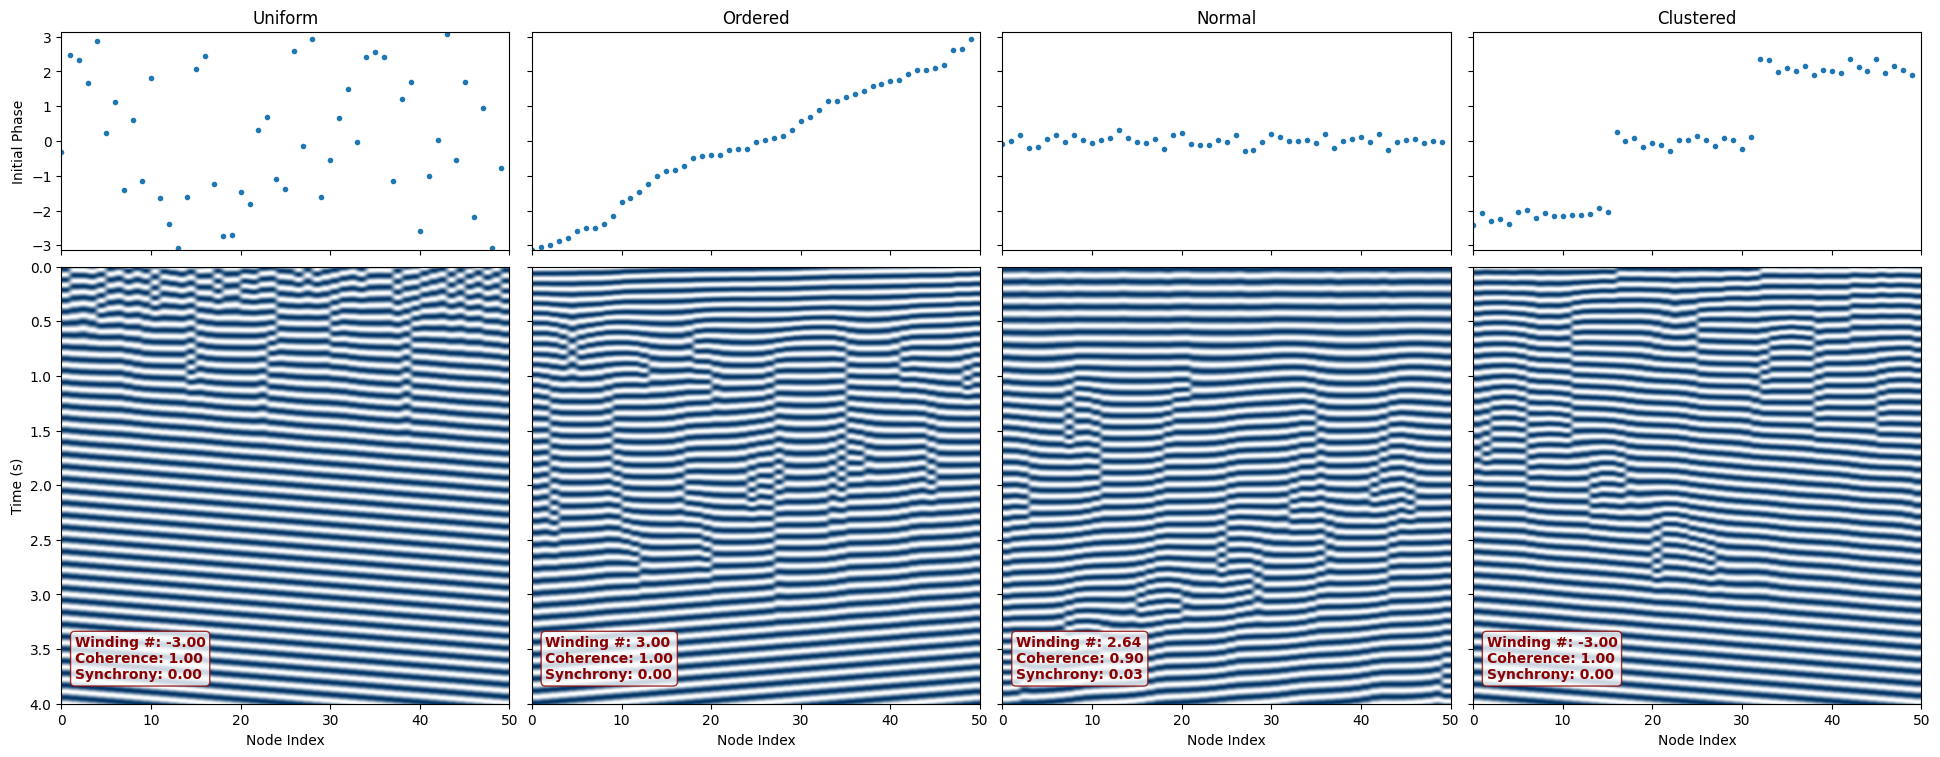

In [6]:

# Parameters
N = 50  # Number of nodes (Small enough to see lines clearly)
DURATION = 4.0          # Seconds
DT = 0.001             # Time step
t_eval = np.arange(0, DURATION, DT)
FREQ = 10 * 2 * np.pi  # 10Hz natural frequency
f = [FREQ]*N
e = 0.5  # Coupling strength

# TODO: One of the experiments at least is to impose distance based delays. 
# Maybe that should be done for all these experiments? 
# Then the clustered delays is more of a structural thing with modular networks


# # Ring with 50% connectivity
A = get_circulant_network(N, 0.5)
D = get_time_delays(A, 'geometric', min=0.002, max=0.062)

# Run experiments
modes = ['uniform', 'ordered', 'normal', 'clustered']
fig, axs = plt.subplots(2, 4, figsize=(20, 8),
                        gridspec_kw={'height_ratios': [1, 2]}, 
                        sharey='row',
                        sharex='col')
for i, mode in enumerate(modes):
    
    theta0 = get_initial_phases(N, mode=mode, wrap=False)
    dKM = run_kuramoto(A, f, theta0, e, t_eval, D=D)
    R_dkm = get_order_parameter(dKM)
    
    axs[0,i].plot(theta0, '.')
    mode_str = mode[0].upper() + mode[1:] # Capitalise first letter
    axs[0,i].set_title(mode_str)
    axs[0,i].set_ylim(-np.pi, np.pi)
    plot_spacetime_heatmap(dKM, DURATION, A, ax=axs[1,i], metrics=['synchrony', 'winding','coherence'])
    axs[1,i].set_xlabel('Node Index')
axs[0,0].set_ylabel('Initial Phase')
axs[1,0].set_ylabel('Time (s)')
plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.05, right=0.98, top=0.92, bottom=0.08)

#### Experiment with noisy geometric delays
* generate a grid of delays with increasing noise
* run the models
* plot all the adjacencies
* plot all the space/times


<>:71: SyntaxWarning: invalid escape sequence '\s'
<>:71: SyntaxWarning: invalid escape sequence '\s'
C:\Users\dgsan\AppData\Local\Temp\ipykernel_30156\1851173138.py:71: SyntaxWarning: invalid escape sequence '\s'
  plot_spacetime_heatmap(dKM, DURATION, A, ax=axs[1,i], metrics=['winding', 'coherence', 'synchrony'], cutoff=0.05, colorbar=True, cbar_label='$\sin \\theta$')


Random seed for get_initial_phases: 970602016
Mean time delay: 0.024823747256103777
Mean time delay: 0.024823747256103777
Mean time delay: 0.02482374725610378
Mean time delay: 0.02482374725610378
Mean time delay: 0.02482374725610378
Mean time delay: 0.02482374725610378
Mean time delay: 0.02482374725610378
Mean time delay: 0.02482374725610378


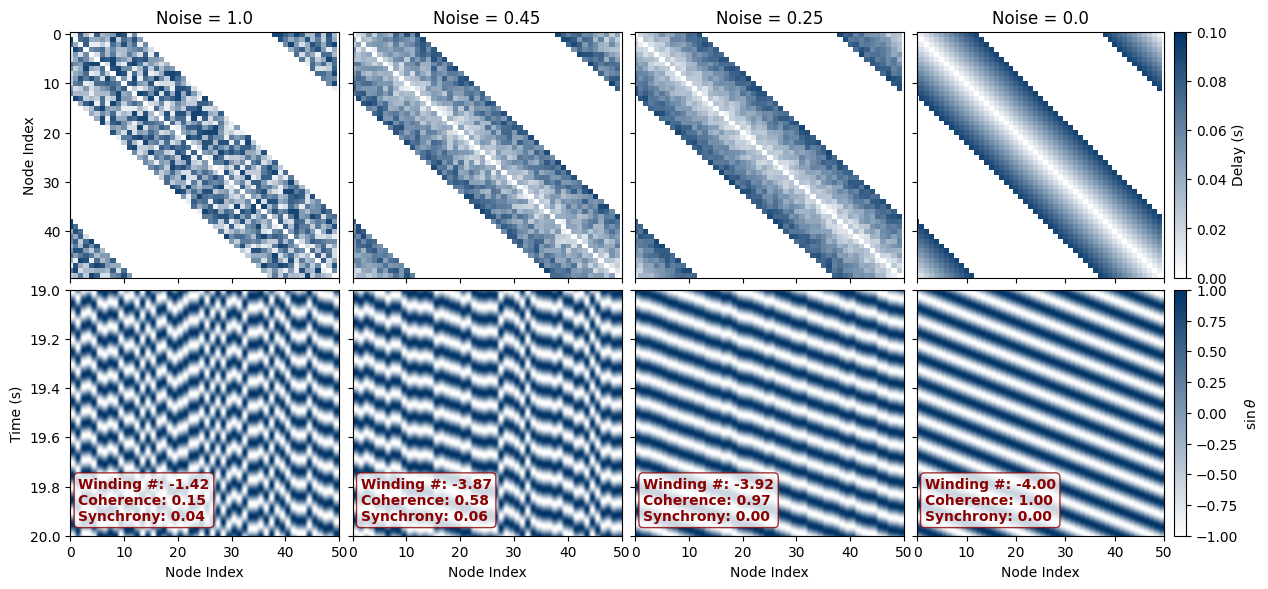

In [8]:
# Parameters
N = 50  # Number of nodes (Small enough to see lines clearly)
DURATION = 20.0          # Seconds
DT = 0.001             # Time step
t_eval = np.arange(0, DURATION, DT)
FREQ = 10 * 2 * np.pi  # 10Hz natural frequency
f = [FREQ]*N
e = 0.5  # Coupling strength
theta0 = get_initial_phases(N, mode='uniform')

# TODO: One of the experiments at least is to impose distance based delays. 
# Maybe that should be done for all these experiments? 
# Then the clustered delays is more of a structural thing with modular networks

def get_time_delays_noisy(A, mode='geometric', **kwargs):
    N = A.shape[0]
    
    if mode == 'geometric':
        velocity = kwargs.get('velocity', 15.0)
        
        # linear geometric delays
        theta = np.linspace(0, 2*np.pi, N, endpoint=False)
        coords = np.column_stack([np.cos(theta), np.sin(theta)])
        dist_matrix = squareform(pdist(coords))
        D = dist_matrix / velocity
        
        # Mask with connectivity - do before shuffle so the mean doesn't explode
        D = D * A
        
        # Add noise
        noise_std = kwargs.get('noise_std', 0.0)
        if noise_std > 0:
            rows, cols = np.where(A > 0)
            geom_values = D[rows, cols]
            rand_values = np.random.permutation(geom_values)
            mixed_values = (1 - noise_std) * geom_values + (noise_std) * rand_values
            D[rows, cols] = mixed_values
            
    return D


# # Ring with 50% connectivity
A = get_circulant_network(N, 0.25)

# Run experiments
noise_levels = [0.0, 0.25, 0.45, 1.0]
n_runs = len(noise_levels)
noise_levels = reversed(noise_levels)
metrics = []
fig, axs = plt.subplots(2, 4, figsize=(12, 6),
                        gridspec_kw={'height_ratios': [1, 1]}, 
                        sharey='row',
                        sharex='col')
for i, noise in enumerate(noise_levels):
    
    D = get_time_delays_noisy(A, 'geometric', min=0.002, max=0.062, noise_std=noise)
    
    # Normalise means so time delay range is controlled
    print(f'Mean time delay: {np.mean(D)}')
    # if i == 0:
    #     target_mean = np.mean(D)
    # else:
    #     D = D * target_mean / np.mean(D)
    # Print mean time delay
    print(f'Mean time delay: {np.mean(D)}')
    dKM = run_kuramoto(A, f, theta0, e, t_eval, D=D)
    R_dkm = get_order_parameter(dKM)
    
    if i == n_runs - 1:
        plot_adjacency_matrix(D, ax=axs[0,i], vmin=0.0, vmax=0.1, colorbar=CMAP_BLUE, cbar_label='Delay (s)')
        plot_spacetime_heatmap(dKM, DURATION, A, ax=axs[1,i], metrics=['winding', 'coherence', 'synchrony'], cutoff=0.05, colorbar=True, cbar_label='$\sin \\theta$')
    else:
        plot_adjacency_matrix(D, ax=axs[0,i], vmin=0.0, vmax=0.1)
        plot_spacetime_heatmap(dKM, DURATION, A, ax=axs[1,i], metrics=['winding', 'coherence', 'synchrony'], cutoff=0.05)
        
    
    axs[0,i].set_title(f'Noise = {noise}', fontsize=12)
    axs[1,i].set_xlabel('Node Index', fontsize=10)
axs[0,0].set_ylabel('Node Index', fontsize=10)
axs[1,0].set_ylabel('Time (s)', fontsize=10)
plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.05, right=0.98, top=0.92, bottom=0.08)
plt.show()


In [13]:
def plot_convergence_dashboard(t_eval, noise_levels, metrics):
    """
    Runs simulations for each noise level and plots convergence metrics.
    """
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(noise_levels)))
    fig, axs = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    
    titles = ["Spatial Coherence", "Winding Number", 
              "Global Synchrony (R)", "Wave Speed"]

    for i, noise in enumerate(noise_levels):
        label = f'$\sigma={noise}$'
        axs[0,0].plot(t_eval, metrics[i]['coherence'], color=colors[i], lw=2, label=label)
        axs[0,1].plot(t_eval, metrics[i]['winding'], color=colors[i], lw=2)
        axs[1,0].plot(t_eval, metrics[i]['synchrony'], color=colors[i], lw=2)
        
        # Speed smoothing for display
        speed_smooth = np.convolve(metrics[i]['speed'], np.ones(10)/10, mode='same')
        axs[1,1].plot(t_eval, speed_smooth, color=colors[i], lw=2)
        
    ax_flat = axs.flatten()
    for j, ax in enumerate(ax_flat):
        ax.set_title(titles[j], fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Time (s)")
        if j == 1: ax.set_ylim(-6.5, 6.5)   # Winding Number (Integers)
        if j == 2: ax.set_ylim(0, 1.05)
        if j == 3: ax.set_ylim(0, 200)      # Speed (Nodes/s) - Cap this to remove any remaining transients

    ax_flat[0].legend(loc='lower right', title="Noise Level")
    plt.tight_layout()
    plt.show()

plot_convergence_dashboard(t_eval, noise_levels, metrics)

<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
C:\Users\dgsan\AppData\Local\Temp\ipykernel_30156\2120827826.py:12: SyntaxWarning: invalid escape sequence '\s'
  label = f'$\sigma={noise}$'


TypeError: object of type 'list_reverseiterator' has no len()

#### Counting stable states (modes) from multiple experiments

Random seed for get_time_delays: 123000583
Running Stability Landscape (21 freqs x 50 trials)...


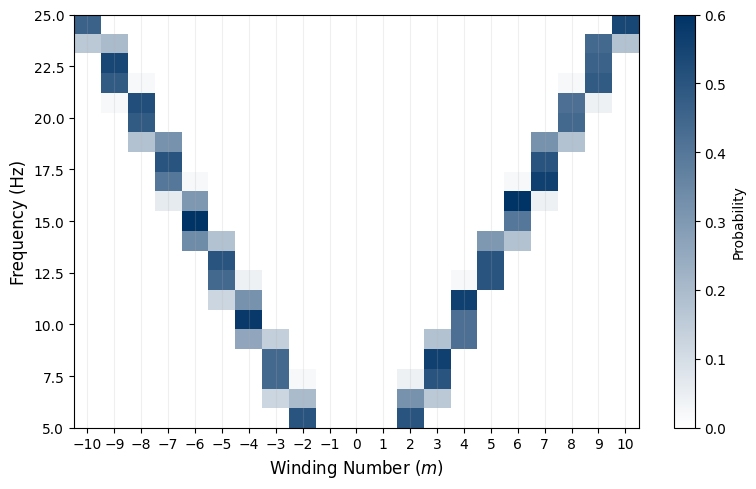

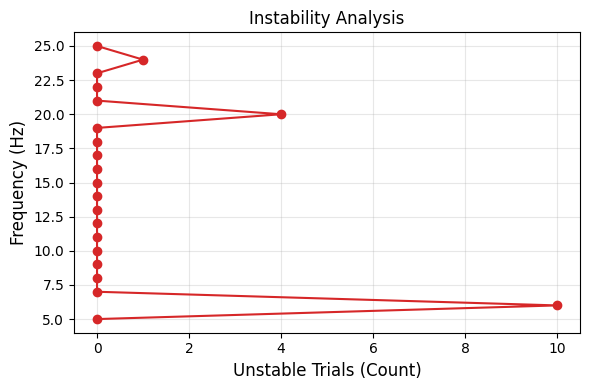

In [18]:
N = 50
DURATION = 100.0  
DT = 0.01        
t_eval = np.arange(0, DURATION, DT)
velocity = 15.0
freqs_hz = np.linspace(5, 25, 21) 
N_TRIALS = 50

# Geometry
A = get_circulant_network(N, 0.25)
D_geom = get_time_delays(A, mode='geometric', velocity=velocity, noise_std=0.0)

# Storage
stability_map = [] 
failure_counts = [] 

def analyze_final_state(final_phases):
    """
    Returns (winding_number, is_stable)
    is_stable is determined by the Global Order Parameter (Coherence).
    """
    # Calculate Winding Number (Topologically Closed)
    phasors = np.exp(1j * final_phases)
    diffs = phasors[1:] * np.conj(phasors[:-1])
    closure = phasors[0] * np.conj(phasors[-1]) # Close the ring
    all_diffs = np.append(diffs, closure)
    
    total_change = np.sum(np.angle(all_diffs))
    m = int(np.round(total_change / (2 * np.pi)))
    phase_diffs = np.angle(all_diffs)
    phase_variance = np.std(phase_diffs)
    
    is_stable = phase_variance < 0.2 
    
    return m, is_stable

print(f"Running Stability Landscape ({len(freqs_hz)} freqs x {N_TRIALS} trials)...")

for f_hz in freqs_hz:
    omega = f_hz * 2 * np.pi
    natural_freqs = [omega] * N
    
    counts = {} 
    failures = 0
    
    for i in range(N_TRIALS):
        # Random Initial Conditions
        theta0 = np.random.uniform(0, 2*np.pi, N)
        
        # Run Sim
        dKM = run_kuramoto(A, natural_freqs, theta0, 0.5, t_eval, D=D_geom)
        
        if dKM.shape[0] == N:
            final_phases = dKM[:, -1]
        else:
            final_phases = dKM[-1, :]
        m, is_stable = analyze_final_state(final_phases)
        if is_stable:
            if m not in counts:
                counts[m] = 0
            counts[m] += 1
        else:
            failures += 1
            
    stability_map.append(counts)
    failure_counts.append(failures)


# Plotting
all_observed_m = set()
for counts in stability_map:
    all_observed_m.update(counts.keys())

if len(all_observed_m) == 0:
    min_m, max_m = -4, 4
else:
    min_m = np.min(list(all_observed_m))
    max_m = np.max(list(all_observed_m))

m_range = np.arange(min_m, max_m + 1)
m_to_idx = {m: i for i, m in enumerate(m_range)}
heatmap_data = np.zeros((len(freqs_hz), len(m_range)))

for i, counts in enumerate(stability_map):
    for m, count in counts.items():
        col_idx = m_to_idx[m]
        heatmap_data[i, col_idx] = count / N_TRIALS

# plot heatmap
fig1, ax_heat = plt.subplots(figsize=(8, 5))
im = ax_heat.imshow(heatmap_data, origin='lower', aspect='auto', cmap=CMAP_BLUE,
                    extent=[min_m - 0.5, max_m + 0.5, np.min(freqs_hz), np.max(freqs_hz)])
cbar = plt.colorbar(im, ax=ax_heat, label='Probability')
ax_heat.set_xlabel("Winding Number ($m$)", fontsize=12)
ax_heat.set_ylabel("Frequency (Hz)", fontsize=12)
ax_heat.set_xticks(m_range)
ax_heat.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

# Plot instability
fig2, ax_fail = plt.subplots(figsize=(6, 4))
ax_fail.plot(failure_counts, freqs_hz, 'o-', color='tab:red') 
ax_fail.set_xlabel("Unstable Trials (Count)", fontsize=12)
ax_fail.set_ylabel("Frequency (Hz)", fontsize=12)
ax_fail.set_title("Instability Analysis", fontsize=12)
ax_fail.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Network Topology - Small world
* Run a series of experiments 
    * Increase rewiring probability - show adjacency and synchrony
    * Use distance based delay, but vary the ratio of neighbour delay to rewire delay


<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:58: SyntaxWarning: invalid escape sequence '\s'
C:\Users\dgsan\AppData\Local\Temp\ipykernel_30156\1917724397.py:58: SyntaxWarning: invalid escape sequence '\s'
  plot_spacetime_heatmap(dKM, DURATION, A, ax=axs[2, i], metrics=['coherence'], cutoff=CUTOFF, colorbar=True, cbar_label='$\sin \\theta$')


Random seed for get_initial_phases: 921543770
Running Small-World Rewiring p=0.0...
Random seed for get_time_delays: 1240031862
Running Small-World Rewiring p=0.1...
Random seed for get_time_delays: 1515075431
Running Small-World Rewiring p=0.2...
Random seed for get_time_delays: 2100830144
Running Small-World Rewiring p=0.4...
Random seed for get_time_delays: 2041820969
Running Small-World Rewiring p=0.8...
Random seed for get_time_delays: 811233398


C:\Users\dgsan\AppData\Local\Temp\ipykernel_30156\1917724397.py:58: SyntaxWarning: invalid escape sequence '\s'
  plot_spacetime_heatmap(dKM, DURATION, A, ax=axs[2, i], metrics=['coherence'], cutoff=CUTOFF, colorbar=True, cbar_label='$\sin \\theta$')


RuntimeError: Colorbar layout of new layout engine not compatible with old engine, and a colorbar has been created.  Engine not changed.

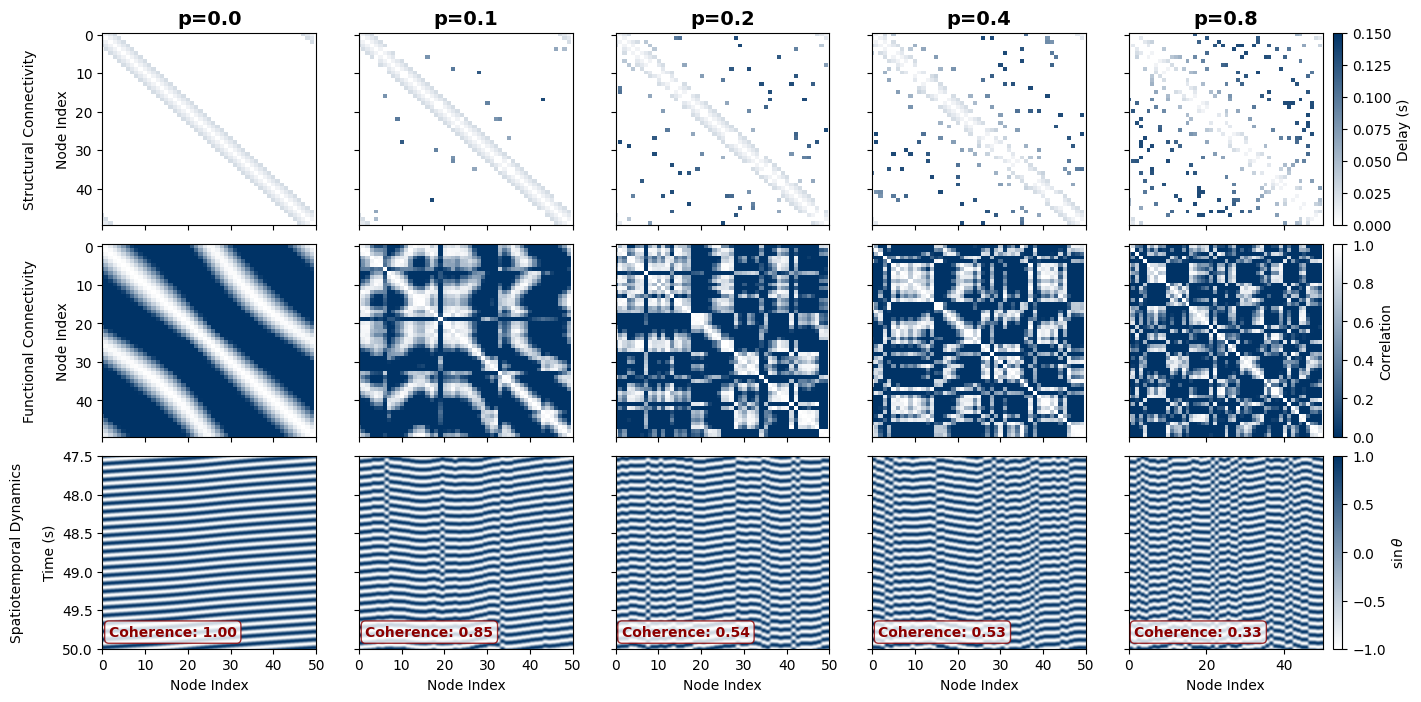

In [19]:
# Parameters
N = 50  # Number of nodes (Small enough to see lines clearly)
DURATION = 50.0          # Seconds
# Set cuttoff to always 5 seconds as a function of duration
CUTOFF = 2.5 / DURATION
DT = 0.001             # Time step
t_eval = np.arange(0, DURATION, DT)
FREQ = 10 * 2 * np.pi  # 10Hz natural frequency
f = [FREQ]*N
e = 0.5  # Coupling strength
theta0 = get_initial_phases(N, mode='uniform')

def phase_locking_value(theta, cutoff=0.5):
    """
    Calculates the Phase Correlation Matrix (Functional Connectivity).
    Correlation of cos(theta) to handle the circularity roughly, 
    or just direct phase coherence cos(theta_i - theta_j).
    """
    # Use the last portion of data
    theta_steady = truncate_time(theta, fraction=cutoff)
    N = theta.shape[1]
    PLV = np.zeros((N, N))
    phasors = np.exp(1j * theta_steady)
    C = np.dot(phasors.T, np.conj(phasors)) / phasors.shape[0]
    PLV = np.abs(C)
    
    return PLV

def cosine_correlation(theta, cutoff=0.5):
    """
    Calculates the instantaneous cosine correlation matrix.
    Result ranges from -1 (anti-phase) to +1 (in-phase).
    """
    theta_steady = truncate_time(theta, fraction=cutoff)
    signals = np.cos(theta_steady)
    correlation_matrix = np.corrcoef(signals.T)
    
    return correlation_matrix

rewiring_probs = [0.0, 0.1, 0.2, 0.4, 0.8]
fig, axs = plt.subplots(3, len(rewiring_probs), figsize=(16, 8), 
                        sharex='col',sharey='row', 
                        gridspec_kw={'wspace': 0.2, 'hspace': 0.1}, constrained_layout=True)

for i, p in enumerate(rewiring_probs):
    print(f"Running Small-World Rewiring p={p}...")
    A = get_smallworld_network(N, 0.15, p)
    D = get_time_delays(A, 'geometric', velocity=15.0)
    dKM = run_kuramoto(A, f, theta0, e, t_eval, D=D)
    PLV = phase_locking_value(dKM, cutoff=CUTOFF)
    corr = cosine_correlation(dKM, cutoff=CUTOFF)
    
    # Plots
    if i == len(rewiring_probs) - 1:
        plot_adjacency_matrix(D, axs[0,i], vmin=0, vmax=0.15, colorbar=True, cbar_label='Delay (s)')
        # plot_adjacency_matrix(PLV, axs[1,i], vmin=0, vmax=1, cmap=CMAP_BLUE_INV, colorbar=True, cbar_label='PLV')
        plot_adjacency_matrix(corr, axs[1,i], vmin=0, vmax=1, cmap=CMAP_BLUE_INV, colorbar=True, cbar_label='Correlation')
        plot_spacetime_heatmap(dKM, DURATION, A, ax=axs[2, i], metrics=['coherence'], cutoff=CUTOFF, colorbar=True, cbar_label='$\sin \\theta$')
    else:
        plot_adjacency_matrix(D, axs[0,i], vmin=0, vmax=0.15)
        # plot_adjacency_matrix(PLV, axs[1,i], vmin=0, vmax=1, cmap=CMAP_BLUE_INV)
        plot_adjacency_matrix(corr, axs[1,i], vmin=0, vmax=1, cmap=CMAP_BLUE_INV)
        plot_spacetime_heatmap(dKM, DURATION, A, ax=axs[2, i], metrics=['coherence'], cutoff=CUTOFF)
        
    
    # Styling
    axs[0, i].set_title(f"p={p}", fontsize=14, fontweight='bold')
    axs[2, i].set_xlabel("Node Index")
    
axs[0, 0].set_ylabel(f"Structural Connectivity\n\nNode Index")
# axs[1, 0].set_ylabel(f"Functional Connectivity\n(Phase Locking Value)\n\nNode Index")
axs[1, 0].set_ylabel(f"Functional Connectivity\n\nNode Index")
axs[2, 0].set_ylabel(f"Spatiotemporal Dynamics\n\nTime (s)")
plt.tight_layout()
plt.show()

#### Network Topology - Modular
* What's a modular network which is good for biological simulation?
* Try to get clustered structure in modular network
* Again, run experiments varying within module vs between module delays

#### Network Topology - HCP
* Run the example data given by Steve
* How does it compare to the synthetic?
* Can I map the data onto a brain image like in the paper and show travelling waves or something?

#### Some network pictures

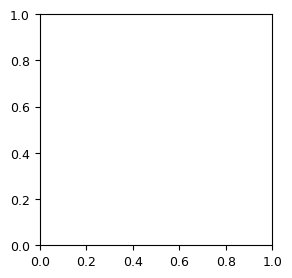

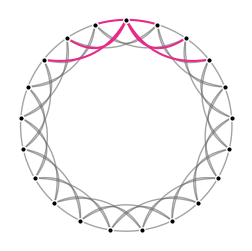

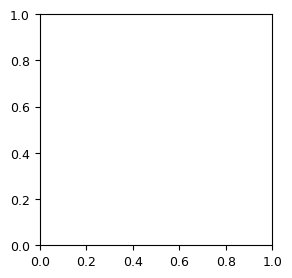

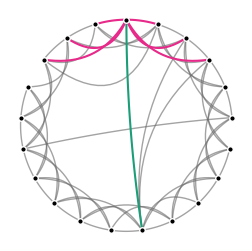

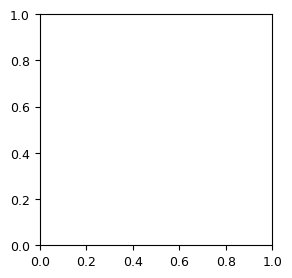

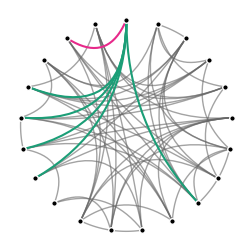

In [24]:
from smallworld.draw import draw_network
from smallworld import get_smallworld_graph

import matplotlib.pyplot as pl

# define network parameters
N = 21
k_over_2 = 3
betas = [0, 0.05, 1.0]
labels = [ r'$\beta=0$', r'$\beta=0.025$', r'$\beta=1$']

focal_node = 0

# scan beta values
for ib, beta in enumerate(betas):

    # generate small-world graphs and draw
    fig, ax = pl.subplots(figsize=(3,3))
    G = get_smallworld_graph(N, k_over_2, beta)
    draw_network(G, k_over_2, focal_node=focal_node)
    pl.show()